Eleanor Stoever

AM 170B

Implementing mHAVOK on the Hindmarsh-Rose neuron model

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.integrate import solve_ivp # for SVD
from sklearn.linear_model import LinearRegression # for computing bst fit linear system
from scipy.signal import find_peaks

# we are implementing mHAVOK manually now, so no need for pydmd's HAVOK

In [13]:
# Defining HR System

# Parameters from:
#   Dynamical phases of the Hindmarsh-Rose neuronal model (Innocenti et al. 2007)
#   r=0.0021, I_ext=3.281 produces chaotic bursting with positive Lyapunov exponent.

def hindmarsh_rose(
    t,
    state,
    a = 1.0,
    b = 3.0,
    c = 1.0,
    d = 5.0,
    r = 0.0021,
    s = 4.0,
    x_rest = -1.6,
    I_ext = 3.281,
):
    """
    Hindmarsh-Rose neuron model:
        dx/dt = y - a*x^3 + b*x^2 - z + I_ext
        dy/dt = c - d*x^2 - y
        dz/dt = r * (s*(x - x_rest) - z)

    Default parameters produce chaotic bursting.
    """
    x, y, z = state
    dx = y - a * x**3 + b * x**2 - z + I_ext
    dy = c - d * x**2 - y
    dz = r * (s * (x - x_rest) - z)
    return [dx, dy, dz]

In [14]:
# HR data generation

def generate_hr_data(
    t_eval,
    **kwargs
):
    """Integrate the Hindmarsh-Rose system and return the state matrix."""
    sol = solve_ivp(
        lambda t, s: hindmarsh_rose(t, s, **kwargs),
        [t_eval[0], t_eval[-1]],
        y0 = [0.0, 0.0, 0.0],
        t_eval = t_eval,
        method = "RK45",
        rtol = 1e-10,
        atol = 1e-12,
    )
    if not sol.success:
        raise RuntimeError(f"ODE integration failed: {sol.message}")
    return sol.y


In [15]:
# Bursts

def get_burst_indices(
    x,
    dt,
    height=0.0,
    min_spike_gap = 5.0,
    min_burst_gap = 50.0
):
    """
    Detect burst onset indices.

    1. Find all individual spike peaks above `height`
    2. Group spikes into bursts by inter-spike gap
    3. For each burst, walk backward from the first spike to find
       when x first crossed `height` upward — the true burst start

    Args:
        x (np.ndarray): Membrane potential time series.
        dt (float): Time step.
        height (float): Threshold above which x is considered active.
        min_spike_gap (float): Minimum time between spikes (time units).
        min_burst_gap (float): Inter-spike gap that signals a new burst (time units).

    Returns:
        np.ndarray: Indices of burst onsets (true start, not spike peak).
    """
    spike_idx, _ = find_peaks(x, height=height, distance=int(min_spike_gap / dt))

    if len(spike_idx) == 0:
        return np.array([], dtype=int)

    # Group spikes into bursts
    gap_samples = int(min_burst_gap / dt)
    first_spikes = [spike_idx[0]]
    for i in range(1, len(spike_idx)):
        if spike_idx[i] - spike_idx[i - 1] > gap_samples:
            first_spikes.append(spike_idx[i])

    # Walk backward from each first spike to find true burst start
    burst_onsets = []
    for spike in first_spikes:
        search_start = max(0, spike - int(50 / dt))
        segment = x[search_start:spike]
        above_seg = (segment > height).astype(int)
        crossings_seg = np.where(np.diff(above_seg) == 1)[0]
        if len(crossings_seg) > 0:
            burst_onsets.append(search_start + crossings_seg[-1])
        else:
            burst_onsets.append(spike)  # fallback to spike peak

    return np.array(burst_onsets)


In [16]:
# Burst Forcing

def get_forcing_burst_indices(
    forcing,
    dt,
    threshold,
    min_burst_gap = 30.0
):
    """
    Find the first threshold crossing of each contiguous active region
    in the forcing signal.

    Args:
        forcing (np.ndarray): Forcing time series.
        dt (float): Time step in seconds.
        threshold (float): Activation threshold for |forcing|.
        min_burst_gap (float): Minimum time between active regions (time units).

    Returns:
        np.ndarray: Indices of predicted burst onsets.
    """
    active = np.abs(forcing) > threshold
    # Find transitions from inactive to active
    transitions = np.diff(active.astype(int))

    onsets = np.where(transitions == 1)[0] + 1 # rising edges
    offsets = np.where(transitions == -1)[0] + 1 # falling edges

    if active[0]:
        onsets = np.insert(onsets, 0, 0)
    if active[-1]:
        offsets = np.append(offsets, len(forcing) - 1)

    if len(onsets) == 0:
        return onsets

    gap_samples = int(min_burst_gap / dt)
    merged = [onsets[0]]
    for i in range(1, len(onsets)):
        gap = onsets[i] - offsets[i - 1]
        if gap > gap_samples:
            merged.append(onsets[i])

    return np.array(merged)


In [17]:
def classify_components(V, dt, tau=0.95):
    """
    Classify embedding components as linear or nonlinear
    by R^2 of linear regression fit. (Eq. 8-10, Colchero et al. 2025)

    Args:
        V (np.ndarray): Full embedding matrix (n, r).
        dt (float): Time step.
        tau (float): R^2 threshold — components below this are nonlinear.

    Returns:
        tuple: (r2_scores, linear_idx, nonlinear_idx)
    """
    V_dot = np.gradient(V, dt, axis=0)
    r2_scores = []

    for i in range(V.shape[1]):
        v_dot_i    = V_dot[:, i]
        coeffs     = np.linalg.lstsq(V, v_dot_i, rcond=None)[0]
        v_dot_pred = V @ coeffs
        ss_res     = np.sum((v_dot_i - v_dot_pred) ** 2)
        ss_tot     = np.sum((v_dot_i - v_dot_i.mean()) ** 2)
        r2         = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        r2_scores.append(r2)

    r2_scores    = np.array(r2_scores)
    linear_idx   = np.where(r2_scores >= tau)[0]
    nonlinear_idx = np.where(r2_scores <  tau)[0]

    return r2_scores, linear_idx, nonlinear_idx

In [18]:
def compute_recall_vs_window(
    true_onsets,
    forcing,
    dt,
    threshold,
    windows = [50.0, 30.0, 20.0, 10.0, 5.0],
    n_random = 10000
):
    """
    For each prediction window size, compute:
    - HAVOK recall: fraction of bursts with forcing active in window before onset
    - Baseline recall: same for random windows (empirical chance level)

    Args:
        true_onsets (np.ndarray): Indices of true burst onsets.
        forcing (np.ndarray): Forcing time series.
        dt (float): Time step.
        threshold (float): Activation threshold.
        windows (list): Prediction window sizes in time units.
        n_random (int): Number of random windows for baseline.

    Returns:
        list[dict]: List of dicts with window, recall, baseline.
    """
    results = []
    for window in windows:
        window_samples = int(window / dt)

        # HAVOK recall
        TP = FN = 0
        for i in range(len(true_onsets) - 1):
            burst_start = true_onsets[i + 1]
            window_start = burst_start - window_samples
            f_start = max(0, min(window_start, len(forcing) - 1))
            f_end = min(burst_start, len(forcing))
            if np.any(np.abs(forcing[f_start:f_end]) > threshold):
                TP += 1
            else:
                FN += 1

        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        # Baseline: random windows
        rand_starts = np.random.randint(0, len(forcing) - window_samples, n_random)
        baseline = np.mean([
            np.any(np.abs(forcing[i:i + window_samples]) > threshold)
            for i in rand_starts
        ])

        results.append(dict(window = window, TP = TP, FN = FN, recall = recall, baseline = baseline))

    return results


In [19]:
def compute_precision_vs_window(
    true_onsets,
    pred_onsets,
    t,
    dt,
    windows = [50.0, 30.0, 20.0, 10.0, 5.0],
):
    """
    For each prediction window size, compute precision:
    fraction of predicted onsets followed by a true burst within the window.

    Args:
        true_onsets (np.ndarray): Indices of true burst onsets.
        pred_onsets (np.ndarray): Indices of predicted burst onsets.
        t (np.ndarray): Time vector.
        dt (float): Time step.
        windows (list): Prediction window sizes in time units.

    Returns:
        list[dict]: List of dicts with window, precision, TP, FP.
    """
    results = []
    for window in windows:
        window_samples = int(window / dt)
        TP = FP = 0
        for p in pred_onsets:
            future_true = true_onsets[true_onsets >= p]
            if len(future_true) > 0 and (future_true[0] - p) <= window_samples:
                TP += 1
            else:
                FP += 1
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        results.append(dict(window=window, TP=TP, FP=FP, precision=precision))
    return results

In [20]:
def compute_lead_times(
    true_onsets,
    pred_onsets,
    t,
    max_lead = None
):
    """
    For each burst, find the last predicted onset before it and compute the lead time.
    Optionally cap at max_lead to exclude contamination from previous burst activity.

    Args:
        true_onsets (np.ndarray): Indices of true burst onsets.
        pred_onsets (np.ndarray): Indices of predicted burst onsets.
        t (np.ndarray): Time vector.
        max_lead (float): Maximum valid lead time.

    Returns:
        np.ndarray: Lead times in time units.
    """
    lead_times = []
    for true_idx in true_onsets:
        preds_before = pred_onsets[pred_onsets < true_idx]
        if len(preds_before) > 0:
            lead = t[true_idx] - t[preds_before[-1]]
            if max_lead is None or lead <= max_lead:
                lead_times.append(lead)
    return np.array(lead_times)

Simulating Hindmarsh-Rose system...
Fitting mHAVOK model...

── mHAVOK component classification (τ=0.95) ─────────────────────
  Linear components:    12  [ 1  2  3  4  5  6  7  8  9 10 11 14]
  Nonlinear components: 3  [12 13 15]
    v01: 0.9553
    v02: 0.9590
    v03: 0.9888
    v04: 0.9759
    v05: 0.9879
    v06: 0.9782
    v07: 0.9866
    v08: 0.9752
    v09: 0.9836
    v10: 0.9645
    v11: 0.9754
    v12: 0.9278 ← nonlinear
    v13: 0.9169 ← nonlinear
    v14: 0.9581
    v15: 0.6190 ← nonlinear

── HAVOK forcing statistics ──────────────────────────────────────
  Threshold:                 0.001987
  Forcing std (overall):     0.001428
  Forcing std (quiescent):   0.001444
  Forcing std (burst):       0.001677
  Fraction of time active:   0.200
  Predicted burst onsets:    308

── Lead time (capped at 39.7 tu) ────────────────────────
  Bursts with valid lead time: 216/216
  Mean lead time:              8.5 time units
  Std lead time:               0.1 time units
  Lead time as 

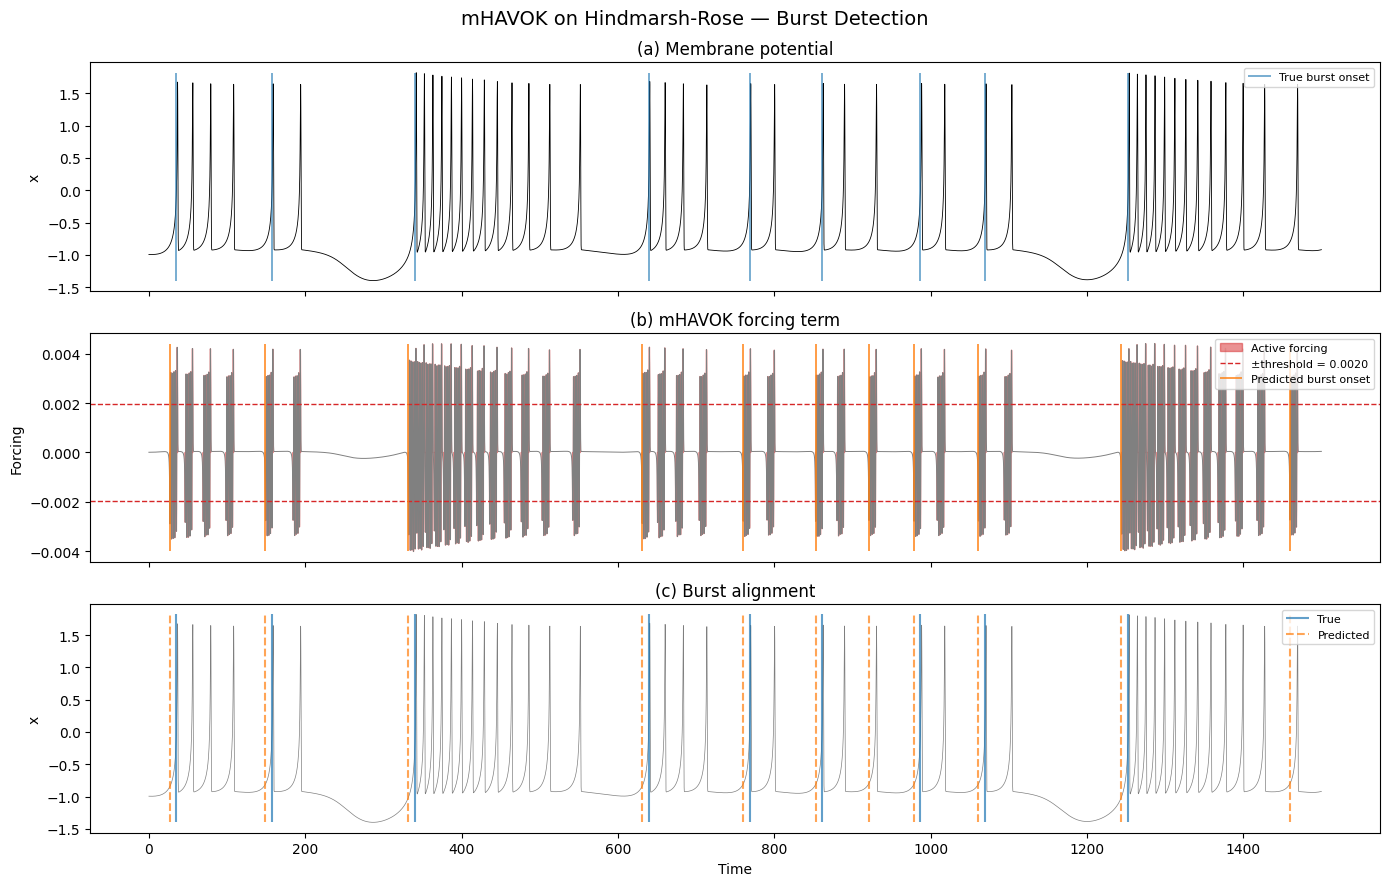

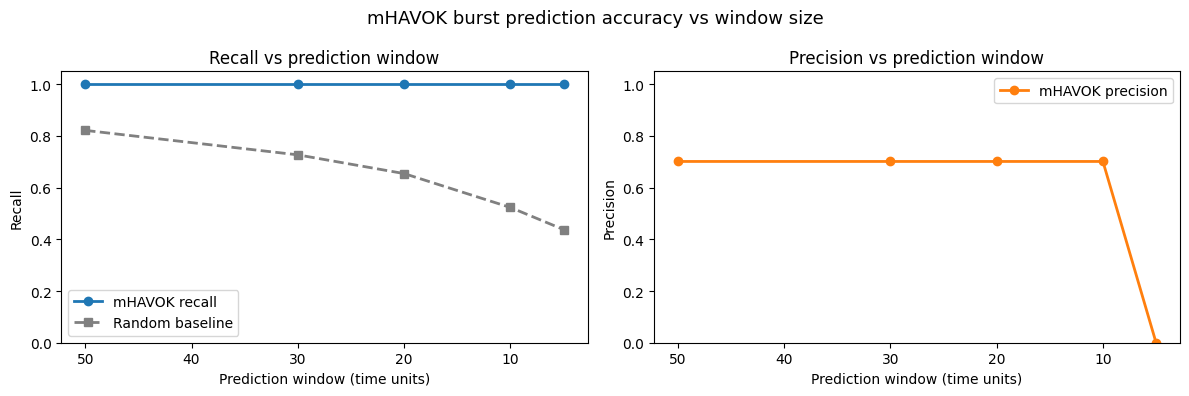

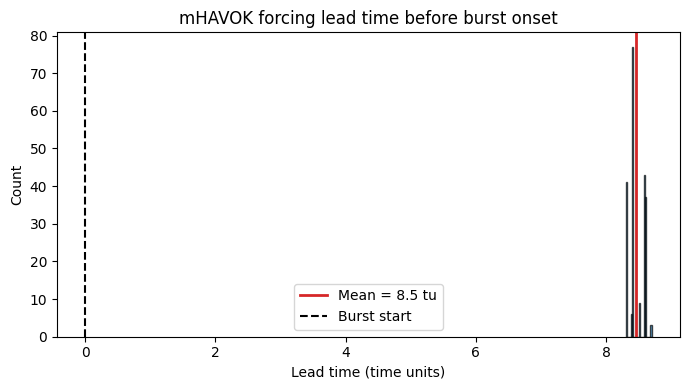

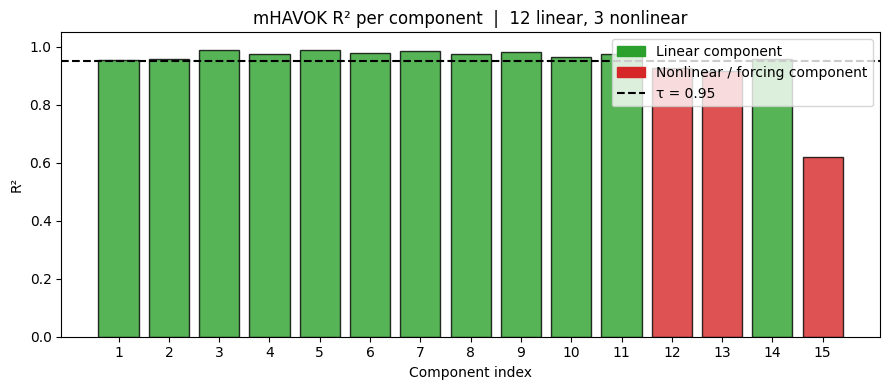

In [21]:
def main():
    # Simulation
    dt = 0.1
    m = 500_000
    t = np.arange(m) * dt

    print("Simulating Hindmarsh-Rose system...")
    X = generate_hr_data(t)

   # Discard transient
    transient = int(950 / dt)

    X_cut = X[:, transient:]
    t = t[transient:] - t[transient]

    x = X_cut[0] # Membrane Potential
    y = X_cut[1] # Recovery Var (this + x(t) gives rapid spikes)
    z = X_cut[2] # Slow Var (slow bursts over long intervals)

    Y = X_cut # mHAVOK uses all three HR variables

    # Ground truth bursts
    true_onsets = get_burst_indices(x, dt)

    # mHAVOK
    print("Fitting mHAVOK model...")

    svd_rank = 15 # chosen (for now)
    delays = 100

    def build_hankel(signal, delays):
        return np.array([
            signal[i : i + len(signal) - delays + 1]
            for i in range(delays)
        ])

    H = np.vstack([build_hankel(channel, delays) for channel in Y])

    U, S, Vh = np.linalg.svd(H, full_matrices=False)

    # Old version: assumes last column is forcing
    # V = Vh[:svd_rank, :].T
    # V_linear = V[:, :svd_rank-1]
    # forcing = V[:, svd_rank-1]
    # forcing_time = t[:len(forcing)]
    # dVdt = np.gradient(V_linear, dt, axis=0)
    # Theta = np.column_stack([V_linear, forcing])
    # Xi = np.linalg.pinv(Theta) @ dVdt
    # A = Xi[:svd_rank-1, :]
    # B = Xi[svd_rank-1:, :]

    # New version: classify components by R^2
    V = Vh[:svd_rank, :].T
    r2_scores, linear_idx, nonlinear_idx = classify_components(V, dt, tau=0.95)

    print(f"\n── mHAVOK component classification (τ=0.95) ─────────────────────")
    print(f"  Linear components:    {len(linear_idx)}  {linear_idx + 1}")
    print(f"  Nonlinear components: {len(nonlinear_idx)}  {nonlinear_idx + 1}")
    for i, r2 in enumerate(r2_scores):
        tag = " ← nonlinear" if i in nonlinear_idx else ""
        print(f"    v{i+1:02d}: {r2:.4f}{tag}")

    V_linear = V[:, linear_idx]
    V_forcing = V[:, nonlinear_idx]

    # Use first nonlinear component as the main forcing signal for burst detection
    forcing = V_forcing[:, 0] if V_forcing.shape[1] > 0 else V[:, -1]
    forcing_time = t[:len(forcing)]

    # Refit A and B using classified components
    dVdt  = np.gradient(V_linear, dt, axis=0)
    Theta = np.column_stack([V_linear, V_forcing])
    Xi    = np.linalg.pinv(Theta) @ dVdt
    A     = Xi[:len(linear_idx), :]
    B     = Xi[len(linear_idx):, :]

    threshold = np.quantile(np.abs(forcing), 0.8)

    true_onsets = true_onsets[true_onsets < len(forcing)]
    pred_onsets = get_forcing_burst_indices(forcing, dt, threshold)

    # Forcing statistics
    q_start = true_onsets[0] + int(50 / dt)
    q_end   = true_onsets[1] - int(50 / dt)
    b_start = true_onsets[0] - int(20 / dt)
    b_end   = true_onsets[0] + int(20 / dt)
    active_fraction = np.mean(np.abs(forcing) > threshold)

    print(f"\n── HAVOK forcing statistics ──────────────────────────────────────")
    print(f"  Threshold:                 {threshold:.6f}")
    print(f"  Forcing std (overall):     {np.std(forcing):.6f}")
    print(f"  Forcing std (quiescent):   {np.std(forcing[q_start:q_end]):.6f}")
    print(f"  Forcing std (burst):       {np.std(forcing[b_start:b_end]):.6f}")
    print(f"  Fraction of time active:   {active_fraction:.3f}")
    print(f"  Predicted burst onsets:    {len(pred_onsets)}")

    # Lead time
    # Cap at half the minimum IBI to exclude contamination from previous burst
    ibi = np.diff(forcing_time[true_onsets])
    max_lead    = 0.5 * ibi.min()
    lead_times  = compute_lead_times(true_onsets, pred_onsets, t, max_lead=max_lead)

    print(f"\n── Lead time (capped at {max_lead:.1f} tu) ────────────────────────")
    print(f"  Bursts with valid lead time: {len(lead_times)}/{len(true_onsets)}")
    print(f"  Mean lead time:              {np.mean(lead_times):.1f} time units")
    print(f"  Std lead time:               {np.std(lead_times):.1f} time units")
    print(f"  Lead time as fraction of IBI: {np.mean(lead_times)/ibi.mean():.2f}")

    # Recall and precision vs window
    windows           = [50.0, 30.0, 20.0, 10.0, 5.0]
    recall_results    = compute_recall_vs_window(true_onsets, forcing, dt, threshold, windows)
    precision_results = compute_precision_vs_window(true_onsets, pred_onsets, t, dt, windows)

    print(f"\n── Recall vs prediction window ───────────────────────────────────")
    print(f"  {'Window':>8}  {'Recall':>8}  {'Baseline':>8}  {'Improvement':>12}")
    for r in recall_results:
        print(f"  {r['window']:>8.1f}  {r['recall']:>8.3f}  "
              f"{r['baseline']:>8.3f}  {r['recall']-r['baseline']:>+12.3f}")

    print(f"\n── Precision vs prediction window ────────────────────────────────")
    print(f"  {'Window':>8}  {'Precision':>10}  {'TP':>6}  {'FP':>6}")
    for r in precision_results:
        print(f"  {r['window']:>8.1f}  {r['precision']:>10.3f}  "
              f"{r['TP']:>6}  {r['FP']:>6}")

# -------------------------------------------------------------
# Plots

    import os
    os.makedirs("plots", exist_ok=True)
    n_plot = min(15_000, len(forcing))

# Use forcing_time instead of t because forcing is shorter than
# the original signal by (delays - 1) samples
    t_plot = forcing_time[:n_plot]
    x_plot = x[:n_plot]
    f_plot = forcing[:n_plot]

# Keep only onsets that fall within plotting range
    in_range = true_onsets[true_onsets < n_plot]
    pred_in_range = pred_onsets[pred_onsets < n_plot]

# ------------------------------------------------------------
# (1) Main detection plot

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle("mHAVOK on Hindmarsh-Rose — Burst Detection", fontsize=14)

# (a) Membrane potential
    ax = axes[0]
    ax.plot(t_plot, x_plot, c="k", lw=0.6)

    if len(in_range) > 0:
        ax.vlines(
            forcing_time[in_range],
            x_plot.min(),
            x_plot.max(),
            color="tab:blue",
            lw=1.2,
            alpha=0.7,
            label="True burst onset"
        )

    ax.set_ylabel("x")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title("(a) Membrane potential")

    # (b) Forcing term
    ax = axes[1]
    ax.plot(t_plot, f_plot, c="gray", lw=0.7)

    ax.fill_between(
        t_plot,
        f_plot,
        where=np.abs(f_plot) > threshold,
        color="tab:red",
        alpha=0.5,
        label="Active forcing"
    )

    ax.axhline(
        threshold,
        c="tab:red",
        ls="--",
        lw=1,
        label=f"±threshold = {threshold:.4f}"
    )
    ax.axhline(-threshold, c="tab:red", ls="--", lw=1)

    if len(pred_in_range) > 0:
        ax.vlines(
            forcing_time[pred_in_range],
            f_plot.min(),
            f_plot.max(),
            color="tab:orange",
            lw=1.2,
            alpha=0.9,
            label="Predicted burst onset"
        )

    ax.set_ylabel("Forcing")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title("(b) mHAVOK forcing term")

    # (c) Alignment plot
    ax = axes[2]
    ax.plot(t_plot, x_plot, c="k", lw=0.5, alpha=0.5)

    if len(in_range) > 0:
        ax.vlines(
            forcing_time[in_range],
            x_plot.min(),
            x_plot.max(),
            color="tab:blue",
            lw=1.5,
            alpha=0.7,
            label="True"
        )

    if len(pred_in_range) > 0:
        ax.vlines(
            forcing_time[pred_in_range],
            x_plot.min(),
            x_plot.max(),
            color="tab:orange",
            lw=1.5,
            alpha=0.7,
            ls="--",
            label="Predicted"
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title("(c) Burst alignment")

    plt.tight_layout()
    plt.savefig("plots/mhavok_hr_burst_detection.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------
    # (2) Recall and precision vs prediction window

    recalls = [r["recall"] for r in recall_results]
    baselines = [r["baseline"] for r in recall_results]
    precisions = [r["precision"] for r in precision_results]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Recall plot
    ax = axes[0]
    ax.plot(windows, recalls, "o-", c="tab:blue", lw=2, label="mHAVOK recall")
    ax.plot(windows, baselines, "s--", c="gray", lw=2, label="Random baseline")
    ax.set_xlabel("Prediction window (time units)")
    ax.set_ylabel("Recall")
    ax.set_title("Recall vs prediction window")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.invert_xaxis()

    # Precision plot
    ax = axes[1]
    ax.plot(
        windows,
        precisions,
        "o-",
        c="tab:orange",
        lw=2,
        label="mHAVOK precision"
    )
    ax.set_xlabel("Prediction window (time units)")
    ax.set_ylabel("Precision")
    ax.set_title("Precision vs prediction window")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.invert_xaxis()

    plt.suptitle("mHAVOK burst prediction accuracy vs window size", fontsize=13)
    plt.tight_layout()
    plt.savefig("plots/mhavok_hr_accuracy_vs_window.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------
    # (3) Lead time hist

    if len(lead_times) > 0:
        fig, ax = plt.subplots(figsize=(7, 4))

        ax.hist(
            lead_times,
            bins=20,
            color="tab:blue",
            edgecolor="k",
            alpha=0.7
        )

        ax.axvline(
            np.mean(lead_times),
            c="tab:red",
            lw=2,
            label=f"Mean = {np.mean(lead_times):.1f} tu"
        )

        ax.axvline(
            0,
            c="k",
            lw=1.5,
            ls="--",
            label="Burst start"
        )

        ax.set_xlabel("Lead time (time units)")
        ax.set_ylabel("Count")
        ax.set_title("mHAVOK forcing lead time before burst onset")
        ax.legend()

        plt.tight_layout()
        plt.savefig("plots/mhavok_hr_lead_times.png", dpi=150)
        plt.show()
    else:
        print("No valid lead times to plot.")

    # ------------------------------------------------------------
    # (4) R^2 per component plot
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ["tab:red" if i in nonlinear_idx else "tab:green"
              for i in range(len(r2_scores))]
    ax.bar(range(1, len(r2_scores) + 1), r2_scores,
           color=colors, edgecolor="k", alpha=0.8)
    ax.axhline(0.95, c="k", ls="--", lw=1.5)
    ax.set_xlabel("Component index")
    ax.set_ylabel("R²")
    ax.set_title(f"mHAVOK R² per component  |  "
                 f"{len(linear_idx)} linear, {len(nonlinear_idx)} nonlinear")
    ax.set_xticks(range(1, len(r2_scores) + 1))
    ax.set_ylim(0, 1.05)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="tab:green", label="Linear component"),
        Patch(color="tab:red",   label="Nonlinear / forcing component"),
        plt.Line2D([0], [0], c="k", ls="--", lw=1.5, label="τ = 0.95"),
    ])
    plt.tight_layout()
    plt.savefig("plots/mhavok_hr_r2_components.png", dpi=150)
    plt.show()

if __name__ == "__main__":
    main()